In [1]:
import time 
import numpy as np
import torch 
from torch import nn
from d2l import torch as d2l

In [29]:
class Animal:
    def __init__(self) -> None:
        pass
class Monkey(Animal):
    def __init__(self) -> None:
        super().__init__()
def add_to_class(Class):
    def wrapper(obj):
        setattr(Class,obj.__name__,obj)
    return wrapper
@ add_to_class(Monkey)
def voice(self):
    print("jiji")
monkey_a=Monkey()
monkey_a.voice()

jiji


In [ ]:
# this function is for the adding elemeent to the initial Class
# in python, a class is allowed no construction function
def add_to_class(Class):
    def wrapper(obj):
        setattr(Class,obj.__name__,obj)
    return wrapper
class A:
    def __init__(self):
        self.b=1
a=A()

In [ ]:
class HyperParameters:
    def save_hyberparameter(self,ignore=[]):
        raise NotImplemented

#所以其实在这个代码里面，在d2l的实现中，ignore已经被封装好了

In [30]:
class ProgressBoard(d2l.HyperParameters):
    def __init__(self, xlabel=None, ylabel=None,xlim=None,ylim=None,xscale="linear",yscale="linear",
                 ls=["-","--","-.",":"],color=["C1","C2","C3","C4"],fig=None,axes=None,figsize=(6,4),
                 display=True):
        self.save_hyperparameters(ignore=[])
    def draw(self,x,y,label,every_n=1):
        raise NotImplemented

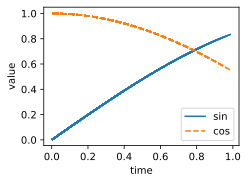

In [33]:
board=d2l.ProgressBoard("time","value")
for x in np.arange(0,1,0.01):
    board.draw(x,np.sin(x),"sin",every_n=2)
    board.draw(x,np.cos(x),"cos",every_n=2)

In [ ]:
# building the linear model from scratch
class Module(nn.Module,d2l.HyperParameters):
    def __init__(self,plot_train_epoch=2,plot_valid_epoch=1):
        super().__init__()
        self.board=ProgressBoard()
        self.save_hyperparameters()
    def loss(self,y_hat,y):
        raise NotImplementedError
    def forward(self,X):
        assert hasattr(self,"net"), 'neural network is defined already'
        ''#here, neual netwok is defined when the self has not attribuate net
        return self.net(X)
    #plot function is used to plot the value of metrics(eg. Mean Squared Error ) and the progress
    def plot(self, key,value, train):
        assert hasattr(self, "trainer"), "Trainer is not inited"
        self.board.xlabel="epoch"
        if train:
            x=self.trainer.train_batch_idx/self.trainer.num_train_batches
            n=self.num_train_batches/ self.plot_train_per_epoch
        else:
            x=self.trainer.epoch+1
            n=self.trainer.num_val_batches/self.plot_valid_per_epoch
        self.board.draw(x,value.to(d2l.cpu()).detach().numpy(),("train_" if train else "val_")+key,every_n=int(n))
    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=True)
        return l

    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=False)

    def configure_optimizers(self):
        raise NotImplementedError

In [ ]:
class DaraModule(d2l.HyperParameters):
    def __init__(self,root="../data",num_workers=4):
        self.save_hyperparameters()
    def get_dataloader(self,train):
        raise NotImplementedError
    def train_dataloader(self):
        return self.get_dataloader(train=True)
    def val_dataloader(self):
        return self.get_dataloader(train=False)

In [ ]:
class Trainer(d2l.HyperParameters):
    def __init__(self,max_epochs,num_gpus=0, gradient_clip_val=0):
        self.save_hyperparameters()
        assert num_gpus==0, "No gpu supports yet"
    def prepare_data(self,data):
        self.train_dataloader=data.train_dataloader()
        self.val_dataloader=data.val_dataloader()
        self.num_train_batches=len(self.train_dataloader)
        self.num_val_batches=(len(self.val_dataloader) if self.val_dataloader else 0)
    def prepare_model(self,model):
        model.trainer=self
        model.board.xlim=[0,self.max_epochs]
        self.model=model
    def fit(self, model, data):
        self.prepare_data(data)
        self.prepare_model(model)
        self.optim=model.optimizers()
        self.epoch=0
        self.train_batch_idx=0
        self.val_bathc_idx=0
        for self.epoch in range(self.max_epochs):
            self.fit_epoch()
    def fit_epoch(self):
        raise NotImplementedError


In [ ]:
#object oriented programming in python
#define the class and object
class Person:
    def __init__(self, age, name):#this is a construction function
        self.name=name
        self.age=age
    def greet(self):              #this is the attribute of the class
        print(f"hello,MY name is {self.name} and my age is {self.age}")
P1=Person("LiHaiyang",27)
P1.greet()

#here there should be something to be differentiated
class Circle:
    pi=3.14 # infact, the common attribute of all the circles are shared
    def __init__(self, radius):
        self.radius=radius
    def area(self):
        print(f"the rightest location of the circle is {self.radius**2*Circle.pi}")#Circle.pi
circle_A=Circle(2)
circle_B=Circle(3)
#here, the attribute converted to the construction function is owned by the circle-A
#However, the common attribute is shared by circle_A, circle_B, ...
circle_A.area()
circle_B.area()


hello,MY name is 27 and my age is LiHaiyang
the rightest location of the circle is 12.56
the rightest location of the circle is 28.26


In [ ]:
#encapsulation
#public this can be used by the class itself, its subclass and external
#protected can be used by the class itself. its subclass, but the external is forbidden
#private can be only be visited by the class itself
class CUHK:
    def __init__(self,location,country,space):
        self.location= location                #location is the public
        self._country= country                  #now the country is the protected
        self.__space=space                     #now the space is the pricate
    def get_space(self):
        return self.__space
mm=CUHK("hk","CHINA","SHATIN")
print(mm.location)
print(mm._country)                             # gentlemen's agreement
#print(mm.__space)

class GRM(CUHK):
    def __init__(self,location,country,space):
        super().__init__(location,country,space)

mm1=GRM("hk","CHINA","SHATIN")
print(mm1.location)
print(mm1._country)                             # gentlemen's agreement
print(mm1.get_space())                          # for the private attribute, we can use the parent class 's function to visit



hk
CHINA
hk
CHINA
SHATIN
say wangwang


In [26]:
###inheritance
#Animal is the parent class of the subclass dog
class Animal:
    def speak(self):
        print("say some sounds")
class Dog(Animal):
    def speak(self):
        print("say wangwang")
zhanmusi=Dog()
zhanmusi.speak()
#using super() to use the construction function of the parent class
class Parent:
    def __init__(self):
        print ("parent initialized")
class Child(Parent):
    def __init__(self):
        super().__init__()
        print("child initialized")
child=Child()# the result will print both parent initialized and child initialized, so that means the construction functions are both executed
##MRO principle
class A:
    def __init__(self) -> None:
        print("A initialized")
class B:
    def __init__(self) -> None:
        print("B initialized")
class C(A,B):
    def __init__(self) -> None:
        super().__init__()
c=C()



say wangwang
parent initialized
child initialized
A initialized


In [ ]:
##